# 4-2. LangGraph Basic RAG

## 학습 목표

- Naive RAG 코드를 LangGraph 구조로 바꾼다.
- 검색 노드와 답변 생성 노드를 분리한다.

## 공통 전제

- 실습 데이터: `../data/공직자_민원응대_핵심_매뉴얼.pdf`
- 기본 모델: `gpt-4o-mini`
- 기본 임베딩 모델: `text-embedding-3-small`
- 벡터DB: Qdrant 로컬 인메모리 모드

> 이 노트북은 `src` 파일을 import하지 않고, 노트북 안의 코드만으로 실행되도록 구성한다.

In [16]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../../.env")

True

## 1. 문서 준비 완료

## 2. 프롬프트와 유틸 함수

In [17]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore

QDRANT_URL = "http://localhost:6333"
COLLECTION_NAME = "civil_complaint_manual_medium"

EMBEDDING_MODEL = "text-embedding-3-small"

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
)

In [18]:
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def format_docs(docs: list[Document]) -> str:
    return "\n\n".join([
        f"[근거 {i}] page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}\n{doc.page_content}"
        for i, doc in enumerate(docs, start=1)
    ])


rag_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 공직자 민원응대 매뉴얼 기반 업무지원 AI입니다.
제공된 근거를 바탕으로만 답변하세요. 질문에 대한 근거가 없으면 없다고 대답하세요.

답변 형식:
1. 핵심 대응
2. 단계별 조치
3. 안내 표현
4. 근거
5. 주의사항
'''),
    ("human", '''
질문:
{question}

근거 문단:
{context}
''')
])

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
rag_chain = rag_prompt | llm | StrOutputParser()

## 3. State 정의

In [19]:
class RAGState(TypedDict):
    question:  str             # 사용자 질문 (입력)
    documents: list[Document]  # 검색된 청크 목록
    context:   str             # format_docs() 결과 (프롬프트용)
    answer:    str             # LLM이 생성한 최종 답변 (출력)


## 4. Node 정의

In [20]:
from langgraph.graph import StateGraph, START, END

# ── retrieve 노드 ──────────────────────────────────────
def retrieve_node(state: RAGState) -> dict:
    question = state["question"]
    docs = vector_store.similarity_search(question, k=4)
    context = format_docs(docs)

    return {
        "documents": docs,
        "context": context
    }

# ── generate 노드 ──────────────────────────────────────
def generate_node(state: RAGState) -> dict:
    answer = rag_chain.invoke({
        "question": state["question"],
        "context": state["context"]
    })

    return {
        "answer": answer
    }

## 5. Graph 구성

In [21]:
# 빌더 생성
graph = StateGraph(RAGState)

# 노드 등록
graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)

# 엣지 연결
graph.add_edge(START,      "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

# 컴파일
app = graph.compile()


### 그래프 시각화

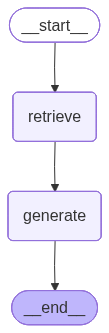

In [22]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 6. 실행

In [23]:
result = app.invoke({
    "question": "민원인이 기관장과 통화하겠다고 요구하면 어떻게 대응해야 하나요?"
})

print(result["answer"])

1. 핵심 대응  
민원인이 기관장과의 통화를 요구할 경우, 기관의 업무 분장과 담당자의 역할을 설명하고, 통화가 불가능한 이유를 안내합니다.

2. 단계별 조치  
- 민원인에게 인사 후 소속을 밝힙니다.  
- 민원인의 요구 사항을 확인하고, 기관장과의 통화가 불가능한 이유를 설명합니다.  
- 필요시 민원인의 성함과 연락처를 받아 담당 팀장이 연락하도록 안내합니다.  
- 통화가 장시간 지속될 경우, 통화를 종료하고 다른 민원 처리를 위해 양해를 구합니다.

3. 안내 표현  
"선생님 말씀하신 민원은 제가 저희 기관 기관장으로부터 민원처리권한을 위임받은 담당자입니다. 해당 업무의 담당자인 제가 말씀을 듣고 도와드릴 수 있습니다. 통화가 20분을 초과하여 다른 민원 처리를 위해 통화를 종료하겠습니다. 양해 부탁드립니다."

4. 근거  
- 민원인의 요구에 끌려가지 말고 기관의 입장을 설명해야 하며, 통화가 장시간 지속될 경우 종료해야 한다는 지침이 있습니다. (근거 1, 2)  
- 민원 상담이 끝나면 인사 후 전화 종료를 권장합니다. (근거 3)

5. 주의사항  
민원인이 폭언이나 협박을 할 경우, 즉시 통화를 종료하고 법적 조치를 고려해야 합니다. 또한, 민원인의 요구가 정당한지 판단하고, 필요시 상급자에게 보고해야 합니다.


## 핵심 정리

```text
START → retrieve → generate → END
```

- 기존 Naive RAG 코드를 검색 노드와 답변 생성 노드로 분리했다.
- 이것이 LangGraph Basic RAG의 기본 구조다.
- 다음 단계에서는 질문 분류, 근거 정리, 답변 검증을 추가해 Modular RAG로 확장한다.